In [ ]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision

In [ ]:
dataset = torchvision.datasets.MNIST('./data',
               transform=torchvision.transforms.ToTensor(),
               download=True)

dataloader = torch.utils.data.DataLoader(dataset,
        batch_size=128,
        shuffle=True)

100%|██████████| 9912422/9912422 [00:00<00:00, 100659782.40it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 111337953.88it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 28800254.01it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 25265953.27it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



# Автокодировщики

Основа туториала для AE и VAE: https://avandekleut.github.io/vae/

## AE

<img src="https://avandekleut.github.io/assets/vae/autoencoder.png" alt="drawing" width="400"/>

In [ ]:
import torch; torch.manual_seed(0)
import torch.nn as nn
import torch.nn.functional as F
import torch.utils
import torch.distributions
import torchvision
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 140

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        return self.linear2(x)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    for epoch in range(1, epochs + 1):
        print(f"Epoch: {epoch}/{epochs}")
        for x, _ in tqdm(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum()
            loss.backward()
            opt.step()
    return autoencoder

In [ ]:
latent_dims = 2
autoencoder = Autoencoder(latent_dims).to(device)

In [ ]:
autoencoder = train(autoencoder, dataloader)

Epoch: 1/20


100%|██████████| 469/469 [00:11<00:00, 41.74it/s]


Epoch: 2/20


100%|██████████| 469/469 [00:13<00:00, 35.54it/s]


Epoch: 3/20


...

100%|██████████| 469/469 [00:07<00:00, 58.66it/s]


Epoch: 19/20


100%|██████████| 469/469 [00:07<00:00, 65.63it/s]


Epoch: 20/20


100%|██████████| 469/469 [00:08<00:00, 57.83it/s]


In [ ]:
@torch.inference_mode()
def plot_latent(autoencoder, dataloader, num_batches=100):
    for i, (x, cls) in enumerate(dataloader):
        if i > num_batches:
            break
        z = autoencoder.encoder(x.to(device))
        z = z.cpu().detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=cls, cmap='tab10')

    plt.colorbar()

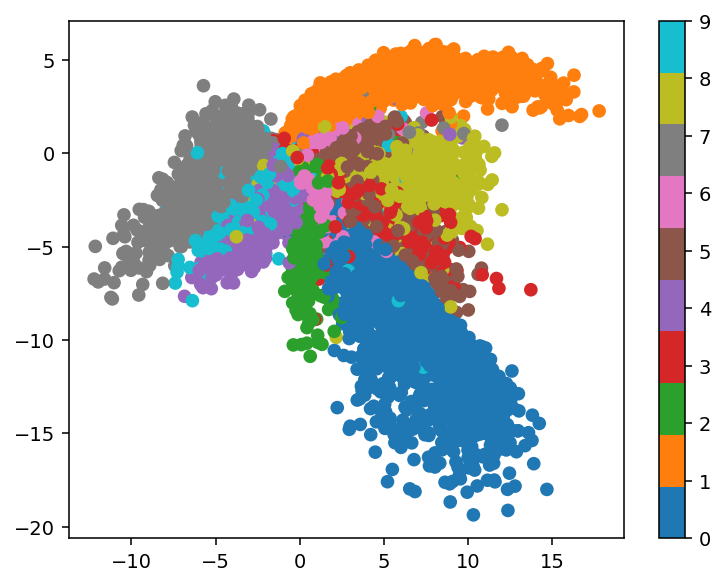

In [ ]:
plot_latent(autoencoder, dataloader)

In [ ]:
@torch.inference_mode()
def plot_reconstructed(autoencoder, r0=(-5, 10), r1=(-10, 5), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = autoencoder.decoder(z)
            x_hat = x_hat.reshape(28, 28).cpu().detach().numpy()
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat
    plt.imshow(img, extent=[*r0, *r1])

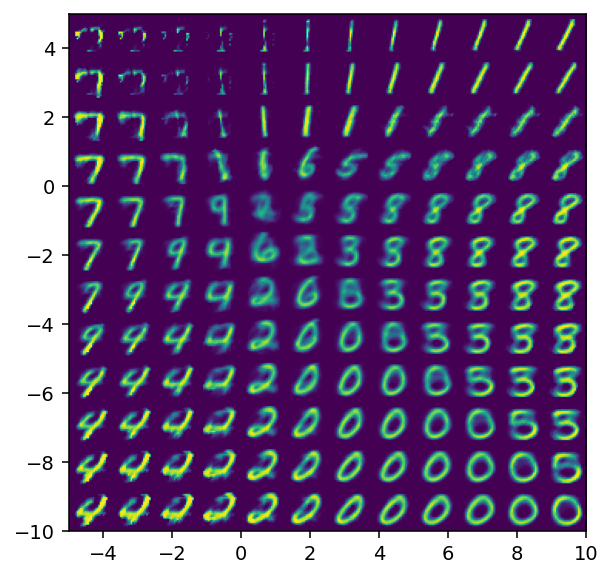

In [ ]:
plot_reconstructed(autoencoder)

## VAE

VAE Paper: https://arxiv.org/pdf/1312.6114.pdf

<img src="https://avandekleut.github.io/assets/vae/variational-autoencoder.png" alt="drawing" width="500"/>

<img src="https://machinelearningmastery.ru/img/0-760222-918525.png" alt="drawing" width="800"/>

In [ ]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.cuda()
        self.N.scale = self.N.scale.cuda()
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu =  self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

In [ ]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [ ]:
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    for epoch in range(1, epochs + 1):
        print(f"Epoch: {epoch}/{epochs}")
        for x, label in tqdm(data):
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat)**2).sum() + autoencoder.encoder.kl
            loss.backward()
            opt.step()
    return autoencoder

In [ ]:
vae = VariationalAutoencoder(latent_dims).to(device)
vae = train(vae, dataloader)

Epoch: 1/20


100%|██████████| 469/469 [00:07<00:00, 61.01it/s]


Epoch: 2/20


100%|██████████| 469/469 [00:08<00:00, 57.60it/s]


Epoch: 3/20


...

100%|██████████| 469/469 [00:08<00:00, 55.76it/s]


Epoch: 19/20


100%|██████████| 469/469 [00:07<00:00, 60.99it/s]


Epoch: 20/20


100%|██████████| 469/469 [00:08<00:00, 56.03it/s]


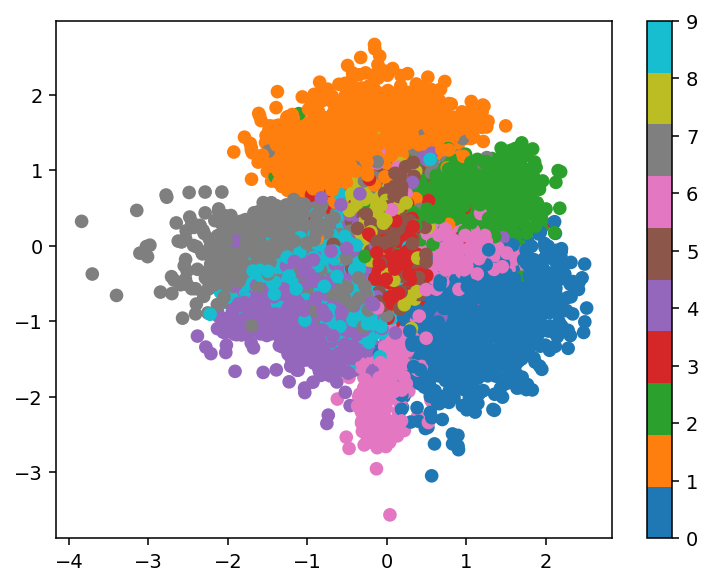

In [ ]:
plot_latent(vae, dataloader)

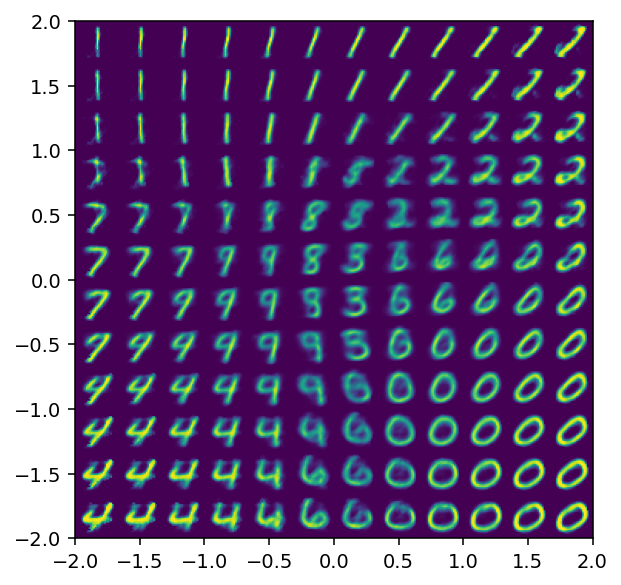

In [ ]:
plot_reconstructed(vae, r0=(-2, 2), r1=(-2, 2))

## VQ-VAE

Paper: https://arxiv.org/pdf/1711.00937.pdf

Хорошие видео:

https://www.youtube.com/watch?v=VZFVUrYcig0

https://www.youtube.com/watch?v=1ZHzAOutcnw

Реализация на PyTorch: https://juliusruseckas.github.io/ml/vq-vae.html

<img src="https://www.andrewszot.com/img/voice_conversion/vq_vae_arch.png" alt="drawing" height="400"/>

### nn.Embedding

Модуль, который по входному индексу выдает хранящееся в таблице значение.

Т.е. этот модуль - Lookup Table (dict/словарь/таблица) - [nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html):

<img src="https://i.postimg.cc/0yYrVwjm/embedding.png" alt="drawing" width="400"/>


In [ ]:
import torch
from torch import nn

In [ ]:
vocab_size = 5
embed_dim = 7
embed = nn.Embedding(vocab_size, embed_dim)
embed.weight

Parameter containing:
tensor([[ 1.7390, -0.2790,  0.2931,  0.4928, -2.4812,  0.8120,  0.6661],
        [ 1.2011,  1.5418,  0.4371,  1.9375,  0.8542,  0.3482,  0.8340],
        [ 2.0460, -1.4961, -0.6479, -1.0218,  1.1934, -0.0418, -1.2973],
        [ 0.7626,  0.4276, -0.7606,  0.4009, -0.4234, -2.5897, -0.3114],
        [ 0.8981,  0.1014,  0.0334,  1.4940, -0.6265,  0.5087, -1.0415]],
       requires_grad=True)

In [ ]:
word_indices = torch.tensor([1,3,0,3,4], dtype=torch.long)
res = embed(word_indices)
res

tensor([[ 1.2011,  1.5418,  0.4371,  1.9375,  0.8542,  0.3482,  0.8340],
        [ 0.7626,  0.4276, -0.7606,  0.4009, -0.4234, -2.5897, -0.3114],
        [ 1.7390, -0.2790,  0.2931,  0.4928, -2.4812,  0.8120,  0.6661],
        [ 0.7626,  0.4276, -0.7606,  0.4009, -0.4234, -2.5897, -0.3114],
        [ 0.8981,  0.1014,  0.0334,  1.4940, -0.6265,  0.5087, -1.0415]],
       grad_fn=<EmbeddingBackward0>)

In [ ]:
res.grad_fn

In [ ]:
res.grad_fn.next_functions
# AccumulateGrad означает, что пришли в корень/лист

((<AccumulateGrad at 0x7bc6abfb1ab0>, 0),)

#### Поиск ближайшего вектора в Embedding

In [ ]:
embed.weight

Parameter containing:
tensor([[ 1.7390, -0.2790,  0.2931,  0.4928, -2.4812,  0.8120,  0.6661],
        [ 1.2011,  1.5418,  0.4371,  1.9375,  0.8542,  0.3482,  0.8340],
        [ 2.0460, -1.4961, -0.6479, -1.0218,  1.1934, -0.0418, -1.2973],
        [ 0.7626,  0.4276, -0.7606,  0.4009, -0.4234, -2.5897, -0.3114],
        [ 0.8981,  0.1014,  0.0334,  1.4940, -0.6265,  0.5087, -1.0415]],
       requires_grad=True)

In [ ]:
x = torch.rand(embed_dim)
x

tensor([0.4560, 0.3325, 0.5087, 0.7533, 0.5994, 0.3244, 0.6272])

In [ ]:
# разные способы посчитать евклидово расстояние
for ind in range(vocab_size):
    print(torch.sqrt(((x - embed.weight[ind]) ** 2).sum()).item())
    print(torch.sqrt(torch.nn.MSELoss(reduction='sum')(x, embed.weight[ind])).item())
    print(torch.cdist(x[None, :], embed.weight[ind][None, :]).item())
    print('-' * 10)

3.4443397521972656
3.4443397521972656
3.4443397521972656
----------
1.8797168731689453
1.8797168731689453
1.8797167539596558
----------
3.81459903717041
3.81459903717041
3.8145992755889893
----------
3.5010557174682617
3.5010557174682617
3.5010557174682617
----------
2.311828374862671
2.311828374862671
2.31182861328125
----------


In [ ]:
torch.cdist(x[None, :], embed.weight)

tensor([[3.4443, 1.8797, 3.8146, 3.5011, 2.3118]], grad_fn=<CdistBackward0>)

In [ ]:
dists = torch.cdist(x.repeat(3, 1), embed.weight)
dists

tensor([[3.4443, 1.8797, 3.8146, 3.5011, 2.3118],
        [3.4443, 1.8797, 3.8146, 3.5011, 2.3118],
        [3.4443, 1.8797, 3.8146, 3.5011, 2.3118]], grad_fn=<CdistBackward0>)

In [ ]:
indices = dists.argmin(dim=-1)
indices

tensor([1, 1, 1])

In [ ]:
embed(indices)

tensor([[1.2011, 1.5418, 0.4371, 1.9375, 0.8542, 0.3482, 0.8340],
        [1.2011, 1.5418, 0.4371, 1.9375, 0.8542, 0.3482, 0.8340],
        [1.2011, 1.5418, 0.4371, 1.9375, 0.8542, 0.3482, 0.8340]],
       grad_fn=<EmbeddingBackward0>)

### Model

In [ ]:
class VQVAEEncoder(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=2):
        super(VQVAEEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(4),
            nn.ReLU(),
        )
        self.pre_quant_layer = nn.Conv2d(4, hidden_channels, kernel_size=1)

    def forward(self, x):
        x = self.encoder(x)
        x = self.pre_quant_layer(x)
        return x

class VQVAEDecoder(nn.Module):
    def __init__(self, hidden_channels=2, out_channels=1):
        super(VQVAEDecoder, self).__init__()
        self.post_quant_layer = nn.Conv2d(hidden_channels, 4, kernel_size=1)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.ConvTranspose2d(16, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.post_quant_layer(x)
        x = self.decoder(x)
        return x

class VQVAE(nn.Module):
    def __init__(self, in_channels=1, hid_channels=2, K=3):
        super(VQVAE, self).__init__()
        self.encoder = VQVAEEncoder(in_channels, hid_channels)
        self.decoder = VQVAEDecoder(hid_channels, in_channels)

        self.embedding = nn.Embedding(num_embeddings=K, embedding_dim=hid_channels)

        self.commitment_cost = 0.2
        self.vq_loss = None

    def forward(self, x):
        # B, C, H, W == x.shape
        encoded = self.encoder(x)

        encoded = encoded.permute(0, 2, 3, 1)
        B, H, W, C = encoded.shape
        encoded = encoded.reshape(B, -1, C)
        # B, H * W, C == encoded.shape
        # B x L x C

        dists = torch.cdist(encoded, self.embedding.weight[None, :].repeat(B, 1, 1))
        embed_indices = dists.argmin(dim=-1)

        embed_out = self.embedding(embed_indices)
        # B, H * W, C == embed_out.shape

        torch.tensor().data
        torch.tensor().grad

        embed_out_connected = encoded + (embed_out - encoded).detach()
        embed_out_connected = embed_out_connected.reshape(B, H, W, C).permute(0, 3, 1, 2)
        # B, C, H, W == embed_out_connected.shape

        reconstructed = self.decoder(embed_out_connected)

        codebook_loss = F.mse_loss(encoded.detach(), embed_out)
        commitment_loss = F.mse_loss(encoded, embed_out.detach())
        self.vq_loss = codebook_loss + self.commitment_cost * commitment_loss

        return reconstructed

In [ ]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

def train(model, data, epochs=5):
    losses = []
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=1, gamma=0.8, verbose=True)
    for epoch in range(1, epochs + 1):
        print(f"Epoch: {epoch}/{epochs}")
        pbar = tqdm(data)
        cur_losses = []
        for x, label in pbar:
            x = x.to(device)
            opt.zero_grad()
            x_hat = model(x)
            loss = F.mse_loss(x, x_hat) + model.vq_loss
            loss.backward()
            opt.step()

            pbar.set_postfix({'loss': loss.item()})
            cur_losses.append(loss.item())
        losses.append(np.array(cur_losses).mean())
        scheduler.step()
    plt.plot(losses)
    plt.show()

Adjusting learning rate of group 0 to 1.0000e-03.
Epoch: 1/5


100%|██████████| 469/469 [00:12<00:00, 36.62it/s, loss=0.0527]


Adjusting learning rate of group 0 to 8.0000e-04.
Epoch: 2/5


100%|██████████| 469/469 [00:10<00:00, 43.46it/s, loss=0.0545]


Adjusting learning rate of group 0 to 6.4000e-04.
Epoch: 3/5


...

Adjusting learning rate of group 0 to 5.1200e-04.
Epoch: 4/5


100%|██████████| 469/469 [00:10<00:00, 43.92it/s, loss=0.0602]


Adjusting learning rate of group 0 to 4.0960e-04.
Epoch: 5/5


100%|██████████| 469/469 [00:10<00:00, 45.84it/s, loss=0.0642]


Adjusting learning rate of group 0 to 3.2768e-04.


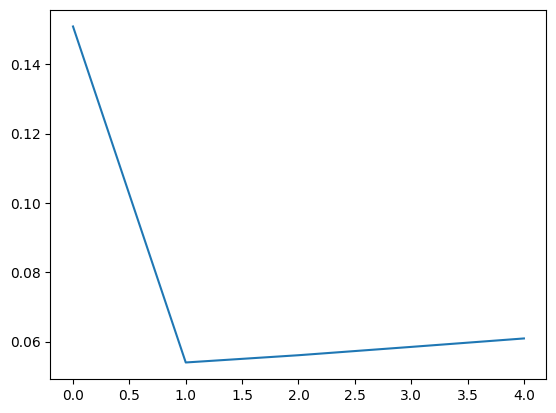

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vqvae = VQVAE(hid_channels=2, K=3).to(device)
train(vqvae, dataloader)

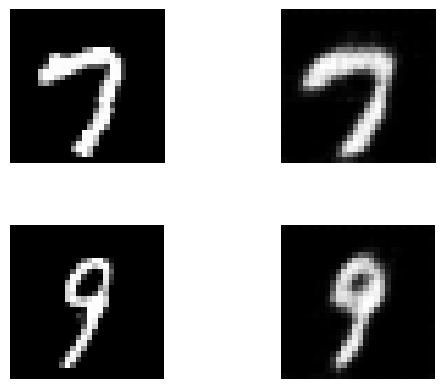

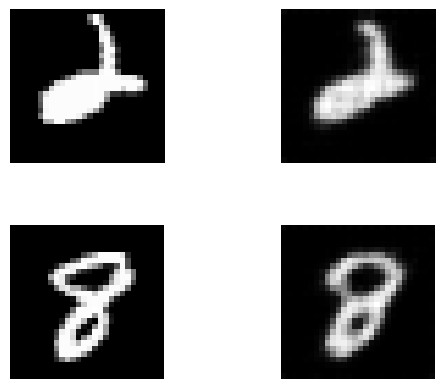

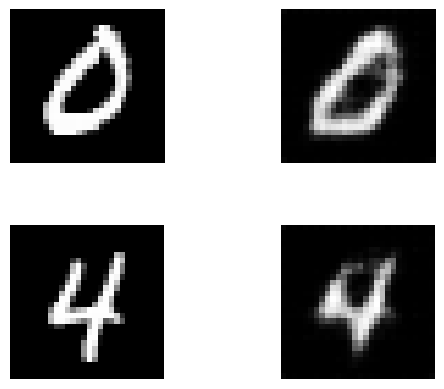

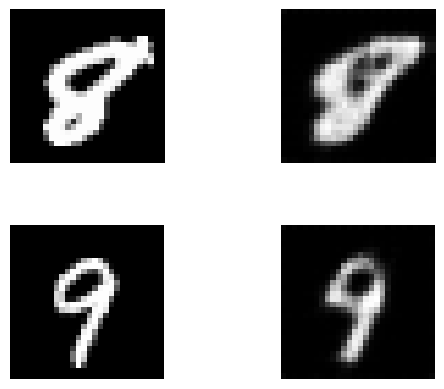

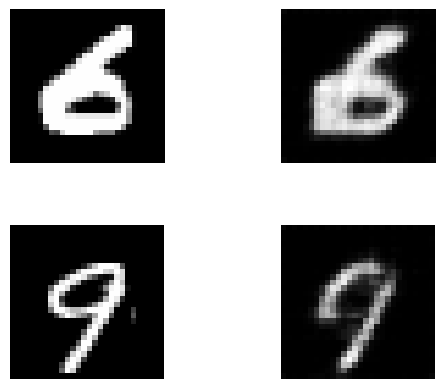

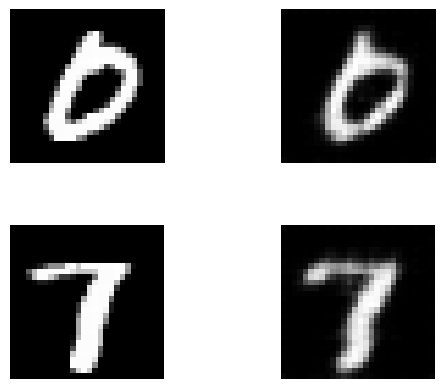

In [ ]:
def plot_images(tensor):
    images = tensor.detach().cpu().numpy()

    B, C, H, W = images.shape
    rows = int(np.sqrt(B))
    cols = int(np.ceil(B / rows))

    fig, axes = plt.subplots(rows, cols)
    fig.subplots_adjust(hspace=0.4)
    for i, ax in enumerate(axes.flat):
        if i < B:
            ax.imshow(np.transpose(images[i], (1, 2, 0)), cmap='gray')
            ax.axis('off')

    plt.show()

def plot_image_pairs(original_images, recon_images):
    original_images = original_images.detach().cpu().numpy()
    recon_images = recon_images.detach().cpu().numpy()

    B, C, H, W = original_images.shape

    fig, axes = plt.subplots(B, 2)
    fig.subplots_adjust(hspace=0.4)
    for i in range(B):
        axes[i, 0].imshow(np.transpose(original_images[i], (1, 2, 0)), cmap='gray')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(np.transpose(recon_images[i], (1, 2, 0)), cmap='gray')
        axes[i, 1].axis('off')

    plt.show()

@torch.inference_mode()
def plot_results_vqvae(vqvae, dataloader, im_in_batches=2, num_batches=5):
    for i, (x, cls) in enumerate(dataloader):
        x = x[:im_in_batches]
        if i > num_batches:
            break
        out = vqvae(x.to(device))
        plot_image_pairs(x, out)
        # plot_images(out)

plot_results_vqvae(vqvae, dataloader)

In [ ]:
batch = next(iter(dataloader))
batch[0].shape

torch.Size([128, 1, 28, 28])

In [ ]:
enc_res = vqvae.encoder(batch[0].to(device))
enc_res.shape

torch.Size([128, 2, 7, 7])

In [ ]:
vqvae.embedding.weight

Parameter containing:
tensor([[-0.4241, -0.7153],
        [ 1.7567, -0.8034],
        [ 0.6104, -0.9730]], device='cuda:0', requires_grad=True)

In [ ]:
bs = 128
rand_hidden_indices = torch.randint(0, vqvae.embedding.num_embeddings, (bs, 7 * 7)).to(device)
rand_hidden = vqvae.embedding(rand_hidden_indices)
rand_hidden = rand_hidden.reshape(bs, 7, 7, vqvae.embedding.embedding_dim).permute(0, 3, 1, 2)
rand_out = vqvae.decoder(rand_hidden)
rand_out.shape

torch.Size([128, 1, 28, 28])

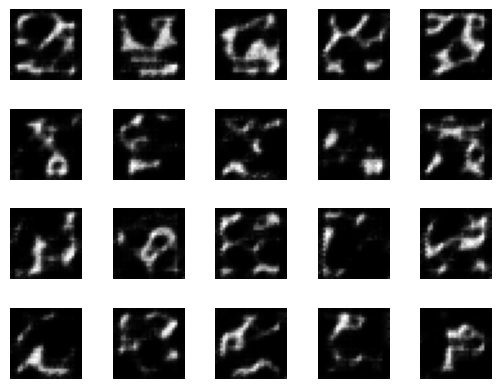

In [ ]:
plot_images(rand_out[:20])

## Conditional VAE

<img src="https://habrastorage.org/r/w1560/web/5aa/22a/e7f/5aa22ae7f85540b289c2f37fdafeb862.png" alt="drawing" width="500"/>

In [ ]:
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims, num_classes):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784 + num_classes, 512)
        self.linear2 = nn.Linear(512, latent_dims)
        self.linear3 = nn.Linear(512, latent_dims)

        self.N = torch.distributions.Normal(0, 1)
        self.N.loc = self.N.loc.cuda() # hack to get sampling on the GPU
        self.N.scale = self.N.scale.cuda()
        self.kl = 0

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu =  self.linear2(x)
        sigma = torch.exp(self.linear3(x))
        z = mu + sigma * self.N.sample(mu.shape)
        self.kl = (sigma**2 + mu**2 - torch.log(sigma) - 1/2).sum()
        return z

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dims, num_classes):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims + num_classes, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))
        return z.reshape((-1, 1, 28, 28))

In [ ]:
class ConditionalVariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims, num_classes):
        super(ConditionalVariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims, num_classes)
        self.decoder = Decoder(latent_dims, num_classes)

    def forward(self, x, labels):
        # Concatenate the input image and conditioning variables
        x = torch.cat((x, labels), dim=1)

        z = self.encoder(x)

        # Concatenate the latent variables and conditioning variables
        z = torch.cat((z, labels), dim=1)
        return self.decoder(z)

In [ ]:
num_classes = 10

def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    for epoch in range(1, epochs + 1):
        print(f"Epoch: {epoch}/{epochs}")
        for x, label in tqdm(data):
            x = x.to(device)
            # Flatten the input images
            x_flat = x.view(-1, 784)
            # One-hot encode the conditioning variables
            y = torch.eye(num_classes)[label].to(device)

            opt.zero_grad()
            x_hat = autoencoder(x_flat, y)
            loss = ((x - x_hat)**2).sum() + autoencoder.encoder.kl
            loss.backward()
            opt.step()

In [ ]:
latent_dims = 20
cvae = ConditionalVariationalAutoencoder(latent_dims, num_classes).to(device)

In [ ]:
train(cvae, dataloader)

Epoch: 1/20


100%|██████████| 469/469 [00:08<00:00, 57.64it/s]


Epoch: 2/20


100%|██████████| 469/469 [00:07<00:00, 59.15it/s]


Epoch: 3/20


...

Epoch: 19/20


100%|██████████| 469/469 [00:07<00:00, 58.78it/s]


Epoch: 20/20


100%|██████████| 469/469 [00:08<00:00, 57.14it/s]


ConditionalVariationalAutoencoder(
  (encoder): VariationalEncoder(
    (linear1): Linear(in_features=794, out_features=512, bias=True)
    (linear2): Linear(in_features=512, out_features=20, bias=True)
    (linear3): Linear(in_features=512, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (linear1): Linear(in_features=30, out_features=512, bias=True)
    (linear2): Linear(in_features=512, out_features=784, bias=True)
  )
)

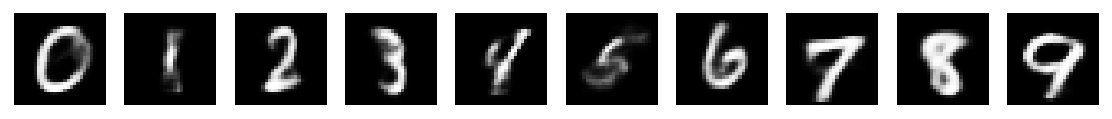

In [ ]:
# Generate samples from the trained CVAE
num_samples = 10
z = torch.randn(num_samples, latent_dims).to(device)
y = torch.eye(num_classes).repeat(num_samples // num_classes + 1, 1)[:num_samples].to(device)
samples = cvae.decoder(torch.cat((z, y), dim=1))

# Display the generated samples (optional)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, num_samples, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].view(28, 28).cpu().detach().numpy(), cmap='gray')
    ax.axis('off')
plt.show()

# GAN

DCGAN Paper: https://arxiv.org/pdf/1511.06434.pdf

Примеры реализации на PyTorch:

https://www.kaggle.com/code/tjac718/dcgan-on-mnist-dataset-using-pytorch

https://www.kaggle.com/code/vyacheslavshen/dcgan-pytorch-tutorial

<img src="https://robocraft.ru/files/neuronet/gan/gan-architecture.png" alt="drawing" width="700"/>

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 7 * 7)
        self.layers = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.fc(x)
        x = x.reshape(-1, 256, 7, 7)
        return self.layers(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout2d(0.25),

            nn.Flatten(),
            nn.Linear(12544, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
latent_dim = 100

generator = Generator(latent_dim)
discriminator = Discriminator()

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

criterion = nn.BCELoss()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_image_grid(tensor):
    images = tensor.detach().cpu().numpy()

    B, _, H, W = images.shape
    rows = int(np.sqrt(B))
    cols = int(np.ceil(B / rows))

    fig, axes = plt.subplots(rows, cols)
    fig.subplots_adjust(hspace=0.4)
    for i, ax in enumerate(axes.flat):
        if i < B:
            ax.imshow(images[i, 0], cmap='gray')
            ax.axis('off')

    plt.show()

In [ ]:
def train(generator, discriminator, generator_optimizer, discriminator_optimizer,
          criterion, dataloader, num_epochs):
    generator.to(device)
    discriminator.to(device)

    for epoch in range(num_epochs):
        for i, (real_images, _) in enumerate(dataloader):
            real_images = real_images.to(device)
            batch_size = real_images.shape[0]

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            noise = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(noise)
            # print(fake_images.shape)

            # Обучение дискриминатора
            discriminator.zero_grad()

            # Дискриминатор обрабатывает реальные и сгенерированные изображения
            real_outputs = discriminator(real_images)
            fake_outputs = discriminator(fake_images.detach())

            # Вычисление функции потерь для дискриминатора и обновление параметров
            discriminator_loss = criterion(real_outputs, real_labels) + criterion(fake_outputs, fake_labels)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            noise = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(noise)
            # Обучение генератора
            generator.zero_grad()
            fake_outputs = discriminator(fake_images)

            # Вычисление функции потерь для генератора и обновление параметров
            generator_loss = criterion(fake_outputs, real_labels)
            generator_loss.backward()
            generator_optimizer.step()

            if i % 100 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {i}/{len(dataloader)}, '
                      f'Discriminator Loss: {discriminator_loss.item()}, Generator Loss: {generator_loss.item()}')

        with torch.no_grad():
            noise = torch.randn(16, latent_dim).to(device)
            fake_images = generator(noise)
            plot_image_grid(fake_images)

Epoch: 1/10, Batch: 0/469, Discriminator Loss: 1.3870688676834106, Generator Loss: 0.7033209800720215
Epoch: 1/10, Batch: 100/469, Discriminator Loss: 1.2391858100891113, Generator Loss: 1.4396851062774658
Epoch: 1/10, Batch: 200/469, Discriminator Loss: 1.1502330303192139, Generator Loss: 1.0439202785491943
Epoch: 1/10, Batch: 300/469, Discriminator Loss: 1.2995274066925049, Generator Loss: 1.042604684829712
Epoch: 1/10, Batch: 400/469, Discriminator Loss: 1.3941679000854492, Generator Loss: 0.8277586698532104


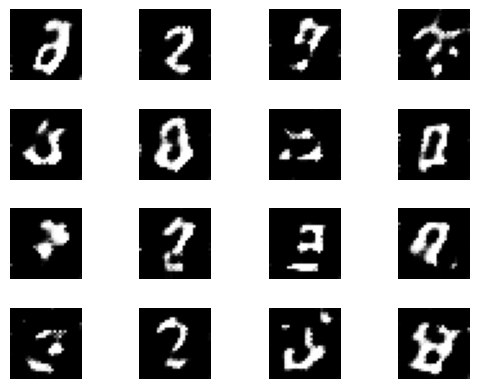

Epoch: 2/10, Batch: 0/469, Discriminator Loss: 1.1997876167297363, Generator Loss: 0.8869542479515076
Epoch: 2/10, Batch: 100/469, Discriminator Loss: 1.1484618186950684, Generator Loss: 0.6881851553916931
Epoch: 2/10, Batch: 200/469, Discriminator Loss: 1.2721726894378662, Generator Loss: 1.4944477081298828
Epoch: 2/10, Batch: 300/469, Discriminator Loss: 1.1163686513900757, Generator Loss: 1.0513496398925781
Epoch: 2/10, Batch: 400/469, Discriminator Loss: 1.1437101364135742, Generator Loss: 0.9907200336456299


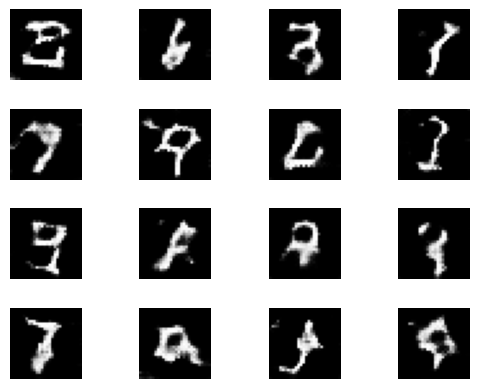

Epoch: 3/10, Batch: 0/469, Discriminator Loss: 1.118794322013855, Generator Loss: 1.2119404077529907
Epoch: 3/10, Batch: 100/469, Discriminator Loss: 1.1467368602752686, Generator Loss: 0.8021523952484131
Epoch: 3/10, Batch: 200/469, Discriminator Loss: 1.2583041191101074, Generator Loss: 1.0525591373443604
Epoch: 3/10, Batch: 300/469, Discriminator Loss: 1.1613517999649048, Generator Loss: 0.9847792387008667
Epoch: 3/10, Batch: 400/469, Discriminator Loss: 1.347891092300415, Generator Loss: 0.9103039503097534


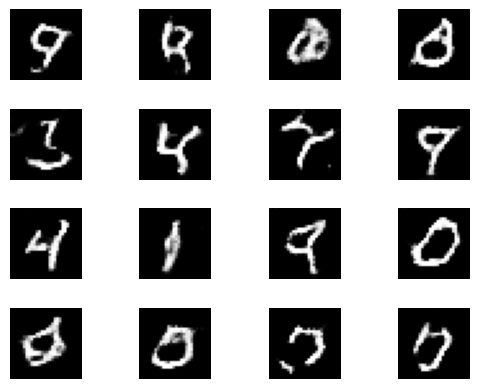

Epoch: 4/10, Batch: 0/469, Discriminator Loss: 1.157637596130371, Generator Loss: 0.816971480846405
Epoch: 4/10, Batch: 100/469, Discriminator Loss: 1.2879204750061035, Generator Loss: 0.8403759598731995
Epoch: 4/10, Batch: 200/469, Discriminator Loss: 1.243912935256958, Generator Loss: 0.9772615432739258
Epoch: 4/10, Batch: 300/469, Discriminator Loss: 1.3071149587631226, Generator Loss: 0.9872454404830933
Epoch: 4/10, Batch: 400/469, Discriminator Loss: 1.1771354675292969, Generator Loss: 0.7299513816833496


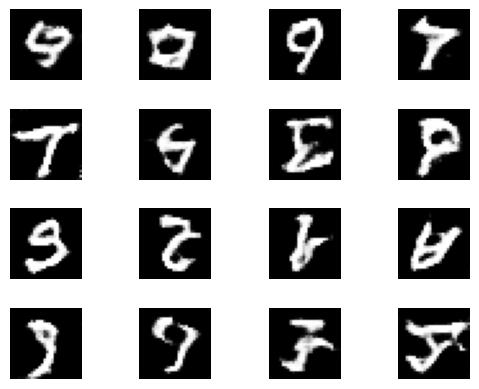

Epoch: 5/10, Batch: 0/469, Discriminator Loss: 1.2229959964752197, Generator Loss: 0.8504109382629395
Epoch: 5/10, Batch: 100/469, Discriminator Loss: 1.3133981227874756, Generator Loss: 0.7867217063903809
Epoch: 5/10, Batch: 200/469, Discriminator Loss: 1.2379112243652344, Generator Loss: 0.9164626598358154
Epoch: 5/10, Batch: 300/469, Discriminator Loss: 1.1926097869873047, Generator Loss: 0.8832275867462158
Epoch: 5/10, Batch: 400/469, Discriminator Loss: 1.2523753643035889, Generator Loss: 0.8129692077636719


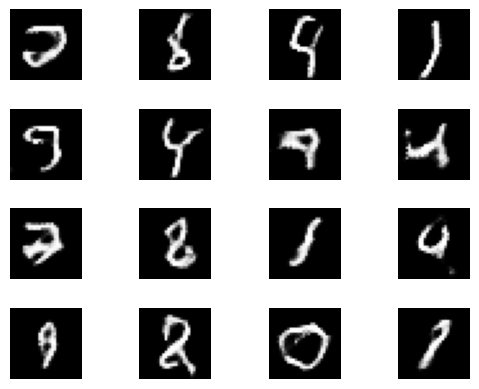

Epoch: 6/10, Batch: 0/469, Discriminator Loss: 1.1989887952804565, Generator Loss: 0.9056527614593506
Epoch: 6/10, Batch: 100/469, Discriminator Loss: 1.2222630977630615, Generator Loss: 0.7819870710372925
Epoch: 6/10, Batch: 200/469, Discriminator Loss: 1.1758451461791992, Generator Loss: 1.0152900218963623
Epoch: 6/10, Batch: 300/469, Discriminator Loss: 1.2753007411956787, Generator Loss: 1.1354490518569946
Epoch: 6/10, Batch: 400/469, Discriminator Loss: 1.135860800743103, Generator Loss: 0.86582350730896


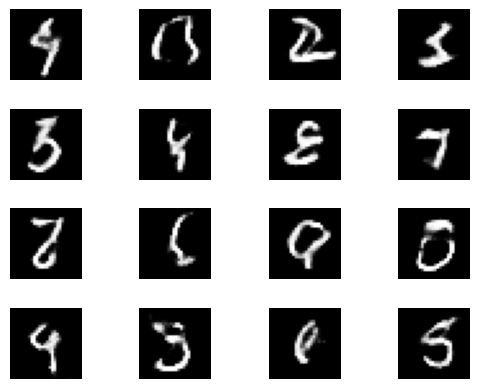

Epoch: 7/10, Batch: 0/469, Discriminator Loss: 1.2133358716964722, Generator Loss: 0.833245038986206
Epoch: 7/10, Batch: 100/469, Discriminator Loss: 1.2792003154754639, Generator Loss: 0.8284686803817749
Epoch: 7/10, Batch: 200/469, Discriminator Loss: 1.1477068662643433, Generator Loss: 0.9721347093582153
Epoch: 7/10, Batch: 300/469, Discriminator Loss: 1.2600457668304443, Generator Loss: 0.8959008455276489
Epoch: 7/10, Batch: 400/469, Discriminator Loss: 1.2145951986312866, Generator Loss: 0.6677172780036926


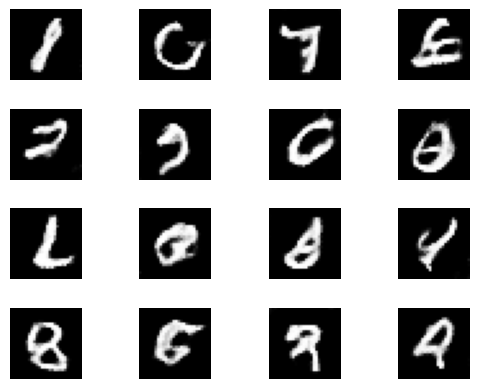

Epoch: 8/10, Batch: 0/469, Discriminator Loss: 1.2688194513320923, Generator Loss: 0.9410400986671448
Epoch: 8/10, Batch: 100/469, Discriminator Loss: 1.189288854598999, Generator Loss: 1.0765860080718994
Epoch: 8/10, Batch: 200/469, Discriminator Loss: 1.2657959461212158, Generator Loss: 0.9858994483947754
Epoch: 8/10, Batch: 300/469, Discriminator Loss: 1.2444976568222046, Generator Loss: 1.0367305278778076
Epoch: 8/10, Batch: 400/469, Discriminator Loss: 1.2493834495544434, Generator Loss: 0.9463459253311157


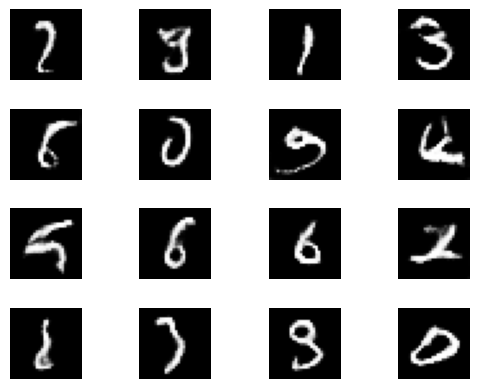

Epoch: 9/10, Batch: 0/469, Discriminator Loss: 1.1889457702636719, Generator Loss: 0.8656316995620728
Epoch: 9/10, Batch: 100/469, Discriminator Loss: 1.1783802509307861, Generator Loss: 0.9265665411949158
Epoch: 9/10, Batch: 200/469, Discriminator Loss: 1.1479949951171875, Generator Loss: 1.0140597820281982
Epoch: 9/10, Batch: 300/469, Discriminator Loss: 1.1980763673782349, Generator Loss: 0.8659476041793823
Epoch: 9/10, Batch: 400/469, Discriminator Loss: 1.2478594779968262, Generator Loss: 1.0437201261520386


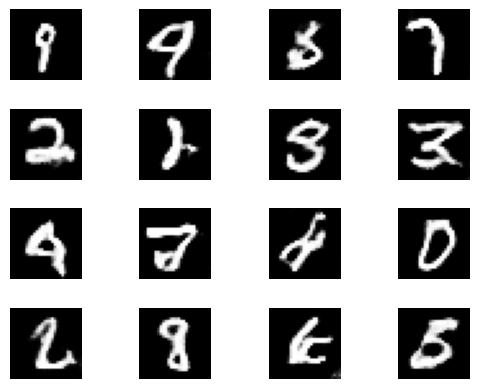

Epoch: 10/10, Batch: 0/469, Discriminator Loss: 1.2009966373443604, Generator Loss: 0.866779625415802
Epoch: 10/10, Batch: 100/469, Discriminator Loss: 1.2623785734176636, Generator Loss: 0.9451154470443726
Epoch: 10/10, Batch: 200/469, Discriminator Loss: 1.3071094751358032, Generator Loss: 0.9372968673706055
Epoch: 10/10, Batch: 300/469, Discriminator Loss: 1.2017581462860107, Generator Loss: 0.9637708067893982
Epoch: 10/10, Batch: 400/469, Discriminator Loss: 1.2892333269119263, Generator Loss: 0.8733328580856323


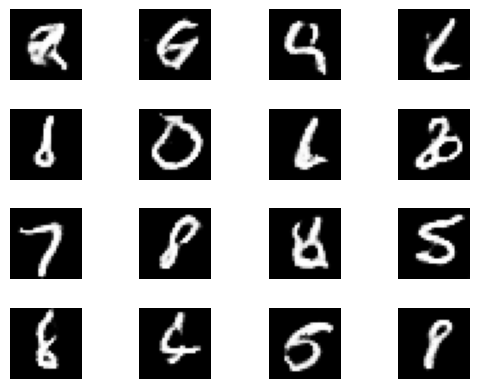

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

num_epochs = 10
train(generator, discriminator,
      generator_optimizer, discriminator_optimizer,
      criterion, dataloader, num_epochs)